# Fitting the full lattice model to sideband spectra

Sideband spectroscopy is how a lattice clock measures its own motional
state. A probe laser scans across the clock transition's carrier and its
axial sidebands, and the resulting spectrum reveals how deep the trap sits
and how warm the atom's radial motion runs. Those two numbers, trap depth
and radial temperature, are the inputs the lattice light shift needs.
Today's practice fits the spectrum with the harmonic-oscillator
model because it has an analytic lineshape, then feeds the fitted numbers
into a separately chosen light shift model, often the more accurate
Born-Oppenheimer-plus-WKB model from notebook 14. Goti et al. 2025 measured
what that mismatch costs directly: discrepancies up to a factor of two in
the extracted radial temperature, and light-shift deviations up to 8e-17.

This notebook fits the spectrum with the same model that predicts the
shift. Both lineshape paths from notebook 14, the harmonic validation
anchor and the Born-Oppenheimer-plus-WKB capability, now generate a full
excitation spectrum, carrier plus red and blue axial sidebands, on the
differentiable JAX core notebook 14's light shift already runs on. A trap
depth and radial temperature come out of a gradient-based fit against that
spectrum, through the identical model that then predicts the light shift.
This is the first gradient-based fit of a Born-Oppenheimer-plus-WKB
sideband lineshape; INRIM's `large-lattice-model` already fits the same
model class by conventional finite-difference-Jacobian least squares, and
this notebook's own cross-validation checks against it directly.

- **Computing the same spectrum two ways, and seeing where they part
  (Section 1).** The harmonic and Born-Oppenheimer-plus-WKB paths, run at
  matched trap depth and temperature, place the blue sideband at different
  positions and give it a different shape.
- **Reproducing an independent open-source implementation's own numbers,
  three tiers (Section 2).** Band-bottom eigenvalues, Franck-Condon
  detunings, and the full sideband shape all check against
  `large-lattice-model` (INRIM), a real third-party implementation of the
  same physics built with a different numerical method.
- **Recovering trap depth and radial temperature from a synthetic spectrum
  by gradient descent (Section 3).** One round trip walked in full, then a
  twelve-case grid, both lineshape models, including the one case whose own
  diagnostics catch a fit that should not be trusted.
- **Handing a lab's own scan to this same model (Section 4).** What comes
  back, and the raw scan data a real trap would still need to supply for
  this same fit to run on measured points.

Five sections follow, in order:

- **Section 1.** The sideband spectrum: what the carrier and each sideband
  encode, computed both ways.
- **Section 2.** Cross-validation against `large-lattice-model`, an
  independent open-source implementation.
- **Section 3.** The fit: a synthetic round trip, then the full grid.
- **Section 4.** What a lab does with this, and the raw-scan partnership
  ask.
- **Section 5.** What an experimental team can use today.


In [1]:
%matplotlib inline
import json
import sys
import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd().parent / "benchmarks"))

import run_sideband_fit as rsf
import run_sideband_spectrum as rss

import cliffordclock.integrator.sideband_spectrum_jax as ssj
from cliffordclock.constants import SPEED_OF_LIGHT
from cliffordclock.ensemble.species import get_species

_notebook_start_s = time.time()
np.set_printoptions(precision=6, suppress=False)

yb171 = get_species("Yb171")
YB171_WAVELENGTH_M = SPEED_OF_LIGHT / rsf.YB171_MAGIC_FREQUENCY_HZ
print(f"species: Yb171, mass = {yb171.mass_kg:.6e} kg")
print(f"magic wavelength: {YB171_WAVELENGTH_M * 1e9:.3f} nm")

species: Yb171, mass = 2.838465e-25 kg
magic wavelength: 759.356 nm


## 1. The sideband spectrum

A clock probe scanned across a lattice site's confined atom sees three
features: the carrier, at the bare clock-transition frequency, and two
axial sidebands, one shifted up by close to the trap's axial vibration
frequency and one shifted down by close to the same amount. The sideband's
own position encodes the trap depth directly, since a deeper trap vibrates
faster along the beam axis. The sideband's own shape, how sharply it peaks
and how far its weight spreads in detuning, encodes the atom's radial
temperature, since a warmer atom samples more of the trap's radial states
and each state shifts the sideband transition by a slightly different
amount. Section 3 recovers both numbers by fitting this shape directly.

The figure below computes one spectrum two ways, at the same trap depth
and the same two temperatures: first with the harmonic validation anchor,
then with the Born-Oppenheimer-plus-WKB capability.


In [2]:
U0_SPECTRUM = 100.0
TZ_SPECTRUM_K = rsf.TEMPERATURE_Z_K
TR_SPECTRUM_K = 1.0e-6
DELTA_SPECTRUM_HZ = jnp.linspace(-50e3, 50e3, 401)

nu_z, nu_r, nu_rec = ssj.blatt_trap_frequencies_hz(
    U0_SPECTRUM, rsf.WAIST_M, YB171_WAVELENGTH_M, yb171.mass_kg
)
print(
    f"u0 = {U0_SPECTRUM:.0f} E_R, Tz = {TZ_SPECTRUM_K * 1e6:.1f} uK, "
    f"Tr = {TR_SPECTRUM_K * 1e6:.1f} uK"
)
print(f"axial trap frequency nu_z = {float(nu_z) / 1e3:.2f} kHz")
print(f"radial trap frequency nu_r = {float(nu_r):.2f} Hz")

t0 = time.perf_counter()
harmonic_spectrum = np.asarray(
    ssj.harmonic_full_spectrum(
        DELTA_SPECTRUM_HZ,
        rsf.PULSE_TIME_S,
        U0_SPECTRUM,
        rsf.WAIST_M,
        YB171_WAVELENGTH_M,
        yb171.mass_kg,
        rsf.PROBE_WAVELENGTH_M,
        rsf.RABI0_HZ,
        TZ_SPECTRUM_K,
        TR_SPECTRUM_K,
        rsf.BLUE_AMPLITUDE,
        rsf.RED_AMPLITUDE,
        rsf.SIDEBAND_LINEWIDTH_HZ,
    )
)
harmonic_time_s = time.perf_counter() - t0

t0 = time.perf_counter()
bowkb_spectrum = np.asarray(
    ssj.bowkb_full_spectrum(
        DELTA_SPECTRUM_HZ,
        rsf.PULSE_TIME_S,
        U0_SPECTRUM,
        rsf.WAIST_M,
        YB171_WAVELENGTH_M,
        yb171.mass_kg,
        rsf.PROBE_WAVELENGTH_M,
        rsf.RABI0_HZ,
        TZ_SPECTRUM_K,
        TR_SPECTRUM_K,
        rsf.BLUE_AMPLITUDE,
        rsf.RED_AMPLITUDE,
        rsf.SIDEBAND_LINEWIDTH_HZ,
    )
)
bowkb_time_s = time.perf_counter() - t0
print(f"harmonic_full_spectrum: {harmonic_time_s:.1f} s, bowkb_full_spectrum: {bowkb_time_s:.1f} s")

delta_khz = np.asarray(DELTA_SPECTRUM_HZ) / 1e3
blue_mask = delta_khz > 3.0
red_mask = delta_khz < -3.0
carrier_mask = np.abs(delta_khz) < 2.0

harmonic_blue_peak_khz = delta_khz[blue_mask][np.argmax(harmonic_spectrum[blue_mask])]
harmonic_blue_peak_val = harmonic_spectrum[blue_mask].max()
harmonic_red_peak_khz = delta_khz[red_mask][np.argmax(harmonic_spectrum[red_mask])]
harmonic_red_peak_val = harmonic_spectrum[red_mask].max()
bowkb_blue_peak_khz = delta_khz[blue_mask][np.argmax(bowkb_spectrum[blue_mask])]
bowkb_blue_peak_val = bowkb_spectrum[blue_mask].max()
bowkb_red_peak_khz = delta_khz[red_mask][np.argmax(bowkb_spectrum[red_mask])]
bowkb_red_peak_val = bowkb_spectrum[red_mask].max()
carrier_peak_val = harmonic_spectrum[carrier_mask].max()

print(f"carrier peak: {carrier_peak_val:.4f}")
print(
    f"harmonic blue sideband peak: {harmonic_blue_peak_val:.4f} at {harmonic_blue_peak_khz:.1f} kHz"
)
print(
    f"harmonic red sideband peak:  {harmonic_red_peak_val:.4f} at {harmonic_red_peak_khz:.1f} kHz"
)
print(f"BO+WKB blue sideband peak:   {bowkb_blue_peak_val:.4f} at {bowkb_blue_peak_khz:.1f} kHz")
print(f"BO+WKB red sideband peak:    {bowkb_red_peak_val:.4f} at {bowkb_red_peak_khz:.1f} kHz")

u0 = 100 E_R, Tz = 2.0 uK, Tr = 1.0 uK
axial trap frequency nu_z = 40.48 kHz
radial trap frequency nu_r = 138.39 Hz


harmonic_full_spectrum: 1.0 s, bowkb_full_spectrum: 10.3 s
carrier peak: 0.0770
harmonic blue sideband peak: 0.6226 at 36.5 kHz
harmonic red sideband peak:  0.5432 at -36.5 kHz
BO+WKB blue sideband peak:   0.3056 at 33.0 kHz
BO+WKB red sideband peak:    0.2724 at -31.5 kHz


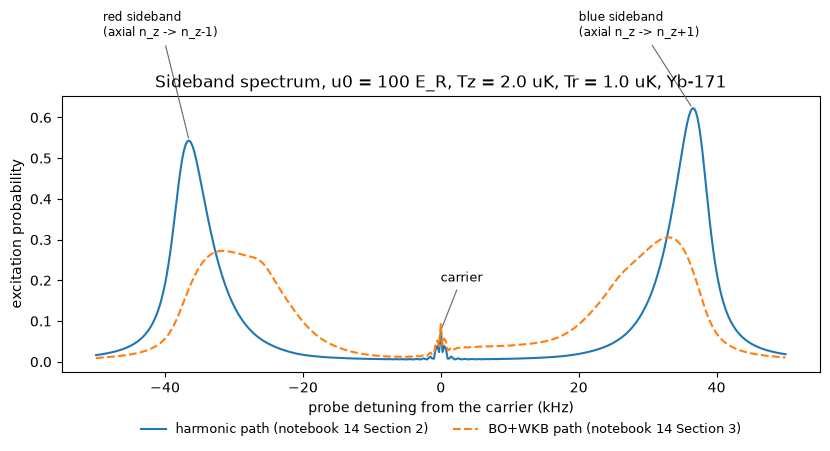

In [3]:
fig, ax = plt.subplots(figsize=(8.4, 5.0))
ax.plot(delta_khz, harmonic_spectrum, color="C0", label="harmonic path (notebook 14 Section 2)")
ax.plot(
    delta_khz,
    bowkb_spectrum,
    color="C1",
    linestyle="--",
    label="BO+WKB path (notebook 14 Section 3)",
)
ax.annotate(
    "carrier",
    xy=(0.0, carrier_peak_val),
    xytext=(3.0, carrier_peak_val + 0.12),
    fontsize=9,
    ha="center",
    arrowprops={"arrowstyle": "-", "color": "0.4", "lw": 0.8},
)
ax.annotate(
    "red sideband\n(axial n_z -> n_z-1)",
    xy=(harmonic_red_peak_khz, harmonic_red_peak_val),
    xytext=(-49.0, 0.80),
    fontsize=8.5,
    ha="left",
    arrowprops={"arrowstyle": "-", "color": "0.4", "lw": 0.8},
)
ax.annotate(
    "blue sideband\n(axial n_z -> n_z+1)",
    xy=(harmonic_blue_peak_khz, harmonic_blue_peak_val),
    xytext=(20.0, 0.80),
    fontsize=8.5,
    ha="left",
    arrowprops={"arrowstyle": "-", "color": "0.4", "lw": 0.8},
)
ax.set_xlabel("probe detuning from the carrier (kHz)")
ax.set_ylabel("excitation probability")
ax.set_title(
    f"Sideband spectrum, u0 = {U0_SPECTRUM:.0f} E_R, Tz = {TZ_SPECTRUM_K * 1e6:.1f} uK, "
    f"Tr = {TR_SPECTRUM_K * 1e6:.1f} uK, Yb-171"
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, fontsize=9, frameon=False)
fig.tight_layout()
plt.show()

The two models place the blue sideband at different positions and give it a
different shape. The harmonic model's blue sideband peaks near the trap's
own axial frequency from the carrier and rises to a sharp maximum. The
Born-Oppenheimer-plus-WKB model's blue sideband peaks at a visibly lower
detuning and spreads its weight across a wider range, printed above and
visible in the figure as the dashed curve's broader, lower hump. Both
differences trace back to a fact notebook 14's Section 4 measured
directly: the true site potential's radial confinement admits more states
per unit energy than a parabola does. A real trap's sideband transition
therefore samples a broader range of Franck-Condon detunings than the
harmonic model's discrete ladder predicts.

One more feature comes from a physical selection rule the forward model
enforces directly, independent of any fit. An atom reaches the red
sideband only by dropping out of its current axial vibrational level, so a
population sitting entirely in the axial ground band has no red sideband
to produce at all. The cell below checks this directly: the same
red-sideband weight function, evaluated at the spectrum's own radial
temperature and again after cooling the axial temperature to within a
nanokelvin of the ground state.


In [4]:
red_weight_at_spectrum_tz = float(
    ssj.harmonic_sideband_shape(
        DELTA_SPECTRUM_HZ,
        -1,
        U0_SPECTRUM,
        rsf.WAIST_M,
        YB171_WAVELENGTH_M,
        yb171.mass_kg,
        TZ_SPECTRUM_K,
        TR_SPECTRUM_K,
        rsf.SIDEBAND_LINEWIDTH_HZ,
    ).max()
)
TZ_GROUND_BAND_K = 1e-9
red_weight_ground_band = float(
    ssj.harmonic_sideband_shape(
        DELTA_SPECTRUM_HZ,
        -1,
        U0_SPECTRUM,
        rsf.WAIST_M,
        YB171_WAVELENGTH_M,
        yb171.mass_kg,
        TZ_GROUND_BAND_K,
        TR_SPECTRUM_K,
        rsf.SIDEBAND_LINEWIDTH_HZ,
    ).max()
)
print(
    f"red-sideband weight peak at Tz = {TZ_SPECTRUM_K * 1e6:.1f} uK: "
    f"{red_weight_at_spectrum_tz:.4f}"
)
print(
    f"red-sideband weight peak at Tz = {TZ_GROUND_BAND_K * 1e9:.0f} nK:  "
    f"{red_weight_ground_band:.4f}"
)

red-sideband weight peak at Tz = 2.0 uK: 0.6781
red-sideband weight peak at Tz = 1 nK:  0.0000


Cooled to the axial ground band, the red-sideband weight computes to
zero, the literal floating-point value printed above. This is the
model's own encoding of Blatt et al.'s stated rule, "there is no
contribution from the longitudinal ground state to the red sideband."
Real traps rarely reach that limit. The spectrum above sits far from it,
with population spread across several axial bands, and its own red
sideband peaks close to the blue one as a result. Section 2 checks this
same forward model against an independent implementation before Section 3
puts it to work fitting a spectrum.


## 2. Cross-validation against an independent implementation

A forward model earns trust from an independent check against a second,
unrelated implementation. `large-lattice-model`
(github.com/inrim/large-lattice-model, MIT license, INRIM, commit
`f569907cdf2f08a9081386139211a205b3c42624`) is a real, public
implementation of the same Born-Oppenheimer-plus-WKB physics, built by the
group that fit real spectroscopy to it in Goti et al. 2025. It solves the
axial eigenproblem with exact Mathieu-function characteristic values, a
different numerical method from this project's own finite-difference
solver, and finds the turning radius by direct root-finding, a different
numerical method again from this module's own table interpolation. This
project reads only that repository's numeric output, generated once in a
separate environment and committed as a fixture; no code from that
repository enters this project.

Three tiers compare this project's own numbers against that fixture,
tightest to loosest. The first two carry this project's own
`independent_implementation_reproduction` class, reproducing an
independent code implementation's output at matched inputs. This
project's established `arithmetic_reproduction` label is reserved for a
paper's own published number. The third tier bridges three
documented lineshape-convention differences (Lorentzian peak height, a
state-dependent versus fixed linewidth, and the integration-domain
cutoff), and carries the weaker `computable_comparison` class, this
project's label for a comparison bridged across a documented convention
gap.


In [5]:
t0 = time.perf_counter()
report2 = rss.build_report()
build_report_time_s = time.perf_counter() - t0
print(f"run_sideband_spectrum.build_report(): {build_report_time_s:.1f} s")

tier1 = report2["tier1_band_energy_reproduction"]
tier2 = report2["tier2_condon_detuning_reproduction"]
tier3 = report2["tier3_sideband_shape_comparison"]
print(f"fixture commit: {report2['fixture_provenance']['commit']}")
print(f"tier1 class: {tier1['case_class']}, kpi_verdict: {tier1['kpi_verdict']}")
print(f"tier2 class: {tier2['case_class']}, kpi_verdict: {tier2['kpi_verdict']}")
print(f"tier3 class: {tier3['case_class']}")

run_sideband_spectrum.build_report(): 24.2 s
fixture commit: f569907cdf2f08a9081386139211a205b3c42624
tier1 class: independent_implementation_reproduction, kpi_verdict: PASS
tier2 class: independent_implementation_reproduction, kpi_verdict: PASS
tier3 class: computable_comparison


**Tier 1: axial band-bottom eigenvalue.** This project's already-gated
finite-difference axial solver against `large-lattice-model`'s exact
Mathieu-characteristic-value eigenvalue, with no Lorentzian, no linewidth,
and no amplitude convention anywhere in the comparison, the tightest
possible check available.[^tier1]


In [6]:
tier1_rows_md = "\n".join(
    f"| {r['depth_er']:.1f} | {r['n_z']} | {r['predicted_er']:.6f} | {r['inrim_er']:.6f} | "
    f"{r['relative_error']:.2e} |"
    for r in tier1["rows"]
)
tier1_table_md = "\n".join(
    [
        "| D (E_R) | n_z | this engine (E_R) | INRIM Mathieu (E_R) | rel. err |",
        "|---|---|---|---|---|",
        tier1_rows_md,
    ]
)
display(Markdown(tier1_table_md))
print(
    f"worst relative error: {tier1['worst_relative_error']:.2e} "
    f"(tolerance {tier1['tolerance_relative']:.0e})"
)
print(f"kpi_verdict: {tier1['kpi_verdict']}")

| D (E_R) | n_z | this engine (E_R) | INRIM Mathieu (E_R) | rel. err |
|---|---|---|---|---|
| 56.8 | 0 | -49.522666 | -49.522666 | 1.42e-09 |
| 56.8 | 1 | -35.530212 | -35.530212 | 9.14e-09 |
| 56.8 | 2 | -22.738976 | -22.738976 | 3.19e-08 |
| 56.8 | 3 | -11.222857 | -11.222856 | 1.06e-07 |
| 80.0 | 0 | -71.313386 | -71.313386 | 1.51e-09 |
| 80.0 | 1 | -54.491064 | -54.491063 | 8.63e-09 |
| 80.0 | 2 | -38.839295 | -38.839294 | 2.82e-08 |
| 80.0 | 3 | -24.506024 | -24.506022 | 7.37e-08 |
| 100.0 | 0 | -90.256779 | -90.256779 | 1.49e-09 |
| 100.0 | 1 | -71.314861 | -71.314861 | 8.45e-09 |
| 100.0 | 2 | -53.520943 | -53.520942 | 2.65e-08 |
| 100.0 | 3 | -37.013512 | -37.013510 | 6.55e-08 |
| 150.0 | 0 | -138.007999 | -138.007999 | 4.42e-10 |
| 150.0 | 1 | -114.559094 | -114.559093 | 2.30e-09 |
| 150.0 | 2 | -92.224232 | -92.224231 | 6.88e-09 |
| 150.0 | 3 | -71.105426 | -71.105425 | 1.39e-08 |

worst relative error: 1.06e-07 (tolerance 1e-04)
kpi_verdict: PASS


Every one of the sixteen rows above lands orders of magnitude inside the
tolerance. This is the strongest available check on this project's own
axial eigensolver, since it isolates the eigenvalue from every downstream
lineshape convention the sideband spectrum itself introduces.

**Tier 2: Franck-Condon detuning.** This work package's own
table-interpolated detuning against `large-lattice-model`'s own
root-find.[^tier2] This module's own resolution is spectrum-scale, lower
than the tighter reference resolution tier 1 exercises. A handful of
points sit within 5 E_R of the band top, where both this module's finite
radial table and `large-lattice-model`'s own fixed-radius bracket
individually lose precision. Those points are flagged and excluded from
the worst-case figure below, with the exclusion's own reason stated
directly.


In [7]:
n_near_top = sum(1 for r in tier2["rows"] if r["near_band_top"])
print(
    f"worst relative error, excluding {n_near_top} of {len(tier2['rows'])} near-band-top points: "
    f"{tier2['worst_relative_error']:.2e} (tolerance {tier2['tolerance_relative']:.0e})"
)
print(f"kpi_verdict: {tier2['kpi_verdict']}")

tier2_depths = sorted({r["depth_er"] for r in tier2["rows"]})
tier2_summary_md = "\n".join(
    [
        "| D (E_R) | points | near-band-top |",
        "|---|---|---|",
        *(
            f"| {d:.1f} | {sum(1 for r in tier2['rows'] if r['depth_er'] == d)} | "
            f"{sum(1 for r in tier2['rows'] if r['depth_er'] == d and r['near_band_top'])} |"
            for d in tier2_depths
        ),
    ]
)
display(Markdown(tier2_summary_md))

worst relative error, excluding 4 of 36 near-band-top points: 4.73e-03 (tolerance 2e-02)
kpi_verdict: PASS


| D (E_R) | points | near-band-top |
|---|---|---|
| 56.8 | 12 | 2 |
| 80.0 | 12 | 1 |
| 100.0 | 12 | 1 |

**Tier 3: full sideband shape, convention-bridged.** The full normalized
sideband shape this notebook's Section 1 plots, against
`large-lattice-model`'s own `sidebands()` output, at two moderate-depth
conditions, each blue and red.[^tier3] Three convention differences are
bridged before any number is compared:

- **Lorentzian peak height.** This project's own Lorentzian peaks at 1;
  `large-lattice-model`'s own peaks at 0.5. Comparing peak-normalized
  shape cancels the difference.
- **Linewidth.** This project uses one fixed value for every state;
  `large-lattice-model` scales each state's own linewidth by its Rabi
  frequency. The bridge uses `large-lattice-model`'s own value directly.
- **Integration domain.** The two sides' own upper-energy cutoffs
  converge at deep trap depth. The bridge compares shapes at the
  moderate depths where both conditions land close together.

What survives the bridge, peak position and peak-normalized shape
correlation, are both convention-independent physical quantities.


In [8]:
tier3_rows_md = "\n".join(
    f"| {r['depth_er']:.1f} | {r['temperature_z_k'] * 1e6:.2f} | "
    f"{r['temperature_r_k'] * 1e6:.2f} | {r['sideband']} | "
    f"{r['inrim_peak_hz'] / 1e3:.1f} | {r['predicted_peak_hz'] / 1e3:.1f} | "
    f"{r['peak_position_difference_hz']:.0f} | {r['shape_correlation']:.4f} |"
    for r in tier3["rows"]
)
tier3_table_md = "\n".join(
    [
        "| D (E_R) | Tz (uK) | Tr (uK) | sideband | INRIM peak (kHz) | this engine (kHz) | "
        "diff (Hz) | shape corr. |",
        "|---|---|---|---|---|---|---|---|",
        tier3_rows_md,
    ]
)
display(Markdown(tier3_table_md))
print(
    f"worst peak-position difference: {tier3['worst_peak_position_difference_hz']:.0f} Hz  "
    f"(on a sideband tens of kHz from the carrier)"
)
print(f"minimum shape correlation: {tier3['min_shape_correlation']:.4f}")

| D (E_R) | Tz (uK) | Tr (uK) | sideband | INRIM peak (kHz) | this engine (kHz) | diff (Hz) | shape corr. |
|---|---|---|---|---|---|---|---|
| 80.0 | 0.30 | 0.30 | blue | 33.0 | 32.5 | 500 | 0.9339 |
| 80.0 | 0.30 | 0.30 | red | -33.0 | -32.5 | 500 | 0.9416 |
| 100.0 | 1.00 | 1.00 | blue | 35.0 | 34.5 | 500 | 0.9852 |
| 100.0 | 1.00 | 1.00 | red | -34.5 | -34.0 | 500 | 0.9864 |

worst peak-position difference: 500 Hz  (on a sideband tens of kHz from the carrier)
minimum shape correlation: 0.9339


Peak position agrees to within half a kilohertz on a sideband tens of
kilohertz from the carrier, and the peak-normalized shape correlates above
0.93 at every row checked. Two independent implementations, one solving
the axial eigenproblem with exact Mathieu-function characteristic values
and one by finite difference, land on the same sideband to this precision
after bridging three documented lineshape-convention differences. Section
3 turns this same forward model into a fit.

[^tier1]: `independent_implementation_reproduction`: reproduces the output
    of `large-lattice-model`, a real third-party open-source
    implementation of Beloy et al. 2020's Born-Oppenheimer-plus-WKB model,
    at matched inputs. This project's `arithmetic_reproduction` class is
    reserved for a paper's own published number. This new class checks
    two independent code implementations against each other.

[^tier2]: `independent_implementation_reproduction`, same class as tier 1,
    exercised at this module's own lower, spectrum-scale numerical
    resolution, below the tighter reference resolution tier 1 uses.

[^tier3]: `computable_comparison`: bridges the documented convention
    differences named above before comparing. This project's label for a
    comparison whose two sides use different, individually documented
    conventions that a comparison must bridge to be meaningful.


## 3. The fit: recovering trap depth and radial temperature from a spectrum

A forward model earns its place in a fitting pipeline by recovering known
truth from noisy data. This section generates one synthetic spectrum from
a known trap depth and radial temperature, adds Gaussian noise at the
level `run_sideband_fit.py` uses throughout, and fits both parameters back
with `scipy.optimize.minimize` supplied exact gradients from
`jax.value_and_grad` of the Born-Oppenheimer-plus-WKB forward model above.
Exact gradients replace `large-lattice-model`'s own finite-difference
Jacobian, one fewer forward evaluation per parameter at every optimizer
iteration.

The fit below runs live, at the same reduced Born-Oppenheimer-plus-WKB
resolution `run_sideband_fit.py` uses for every case in its own grid
(`FIT_AXIAL_GRID_N=241` against Section 1's `AXIAL_GRID_N_SPECTRUM=321`).
That resolution is chosen for a full optimizer run to complete in a few
seconds, and verified in that script's own module docstring to agree with
the full-resolution defaults to a few percent, comfortably inside this
demonstration's own noise floor.


In [9]:
FIT_TRUTH_U0 = 100.0
FIT_TRUTH_TR_K = 1.0e-6
FIT_SEED = 0


def bowkb_forward_fit_resolution(u0, tr):
    carrier = ssj.harmonic_carrier_excitation_probability(
        rsf.DELTA_GRID_HZ,
        rsf.PULSE_TIME_S,
        u0,
        rsf.WAIST_M,
        YB171_WAVELENGTH_M,
        yb171.mass_kg,
        rsf.PROBE_WAVELENGTH_M,
        rsf.RABI0_HZ,
        rsf.TEMPERATURE_Z_K,
        tr,
    )
    blue = ssj.bowkb_sideband_shape(
        rsf.DELTA_GRID_HZ,
        1,
        u0,
        rsf.WAIST_M,
        YB171_WAVELENGTH_M,
        yb171.mass_kg,
        rsf.TEMPERATURE_Z_K,
        tr,
        rsf.SIDEBAND_LINEWIDTH_HZ,
        n_z_max=rsf.FIT_N_Z_MAX_BOWKB,
        n_e_quad=rsf.FIT_N_E_QUAD,
        axial_grid_n=rsf.FIT_AXIAL_GRID_N,
        rho_table_n=rsf.FIT_RHO_TABLE_N,
    )
    red = ssj.bowkb_sideband_shape(
        rsf.DELTA_GRID_HZ,
        -1,
        u0,
        rsf.WAIST_M,
        YB171_WAVELENGTH_M,
        yb171.mass_kg,
        rsf.TEMPERATURE_Z_K,
        tr,
        rsf.SIDEBAND_LINEWIDTH_HZ,
        n_z_max=rsf.FIT_N_Z_MAX_BOWKB,
        n_e_quad=rsf.FIT_N_E_QUAD,
        axial_grid_n=rsf.FIT_AXIAL_GRID_N,
        rho_table_n=rsf.FIT_RHO_TABLE_N,
    )
    return carrier + rsf.BLUE_AMPLITUDE * blue + rsf.RED_AMPLITUDE * red


truth_spectrum_fit = np.asarray(
    bowkb_forward_fit_resolution(jnp.asarray(FIT_TRUTH_U0), jnp.asarray(FIT_TRUTH_TR_K))
)
rng = np.random.default_rng(FIT_SEED)
noisy_spectrum = truth_spectrum_fit + rng.normal(
    0.0, rsf.NOISE_SIGMA, size=truth_spectrum_fit.shape
)

t0 = time.perf_counter()
fit_case = rsf.run_one_fit("bowkb", FIT_TRUTH_U0, FIT_TRUTH_TR_K, FIT_SEED)
fit_time_s = time.perf_counter() - t0
print(
    f"run_one_fit (bowkb, u0={FIT_TRUTH_U0:.0f}, Tr={FIT_TRUTH_TR_K * 1e6:.1f} uK, "
    f"seed={FIT_SEED}): {fit_time_s:.1f} s, {fit_case.n_iterations} L-BFGS-B iterations"
)

fit_curve = np.asarray(
    bowkb_forward_fit_resolution(
        jnp.asarray(fit_case.recovered_u0), jnp.asarray(fit_case.recovered_tr_k)
    )
)
print(f"truth:     u0 = {FIT_TRUTH_U0:.2f} E_R, Tr = {FIT_TRUTH_TR_K * 1e6:.3f} uK")
print(
    f"recovered: u0 = {fit_case.recovered_u0:.2f} +/- "
    f"{fit_case.recovered_u0_uncertainty:.2f} E_R, "
    f"Tr = {fit_case.recovered_tr_k * 1e6:.3f} +/- "
    f"{fit_case.recovered_tr_k_uncertainty * 1e6:.3f} uK"
)

run_one_fit (bowkb, u0=100, Tr=1.0 uK, seed=0): 18.4 s, 12 L-BFGS-B iterations


truth:     u0 = 100.00 E_R, Tr = 1.000 uK
recovered: u0 = 100.01 +/- 0.49 E_R, Tr = 0.996 +/- 0.028 uK


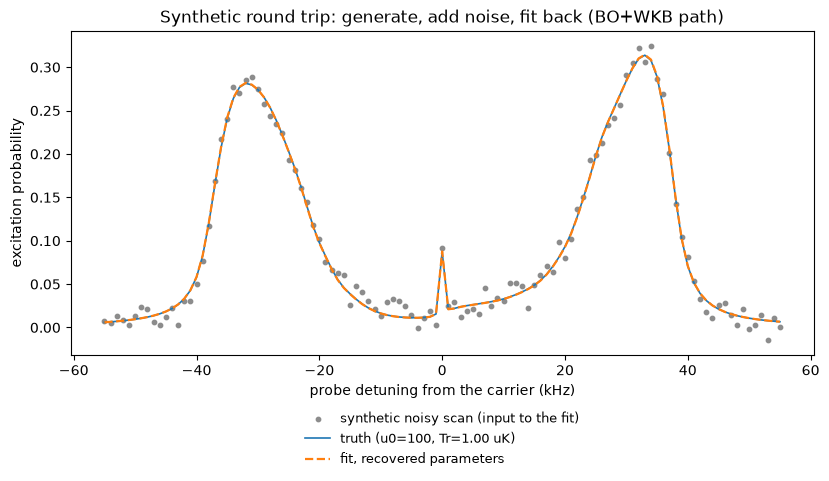

In [10]:
fig, ax = plt.subplots(figsize=(8.4, 5.0))
delta_fit_khz = np.asarray(rsf.DELTA_GRID_HZ) / 1e3
ax.scatter(
    delta_fit_khz,
    noisy_spectrum,
    s=10,
    color="0.55",
    label="synthetic noisy scan (input to the fit)",
)
ax.plot(
    delta_fit_khz, truth_spectrum_fit, color="C0", linewidth=1.2, label="truth (u0=100, Tr=1.00 uK)"
)
ax.plot(
    delta_fit_khz,
    fit_curve,
    color="C1",
    linestyle="--",
    linewidth=1.6,
    label="fit, recovered parameters",
)
ax.set_xlabel("probe detuning from the carrier (kHz)")
ax.set_ylabel("excitation probability")
ax.set_title("Synthetic round trip: generate, add noise, fit back (BO+WKB path)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=1, fontsize=9, frameon=False)
fig.tight_layout()
plt.show()

The fit curve tracks the noisy data closely enough to sit inside the
truth curve at almost every point, and the recovered trap depth and
radial temperature both land within their own reported one-sigma
uncertainty of the values that generated the spectrum. One round trip
demonstrates the method works. A twelve-case grid, three truth points,
two noise seeds, both lineshape models, checks whether it works
consistently. The table below reuses `run_sideband_fit.py`'s own
committed results for that grid, generated the same way the walkthrough
above just ran.


In [11]:
fit_artifact_path = Path("..") / "benchmarks" / "results" / "wp38_sideband_fit.json"
fit_report = json.loads(fit_artifact_path.read_text(encoding="utf-8"))
print(f"source: {fit_artifact_path}")
print(f"{fit_report['n_converged']}/{fit_report['n_cases']} fits converged")
print(
    f"{fit_report['n_hessian_positive_definite']}/{fit_report['n_cases']} report a "
    f"positive-definite Hessian"
)
print(
    f"{fit_report['n_within_1sigma_both_params']}/{fit_report['n_cases']} within 1-sigma, "
    f"{fit_report['n_within_2sigma_both_params']}/{fit_report['n_cases']} within 2-sigma"
)


def uncertainty_cell(recovered, uncertainty, hessian_pd, decimals):
    if not hessian_pd:
        return f"{recovered:.{decimals}f} +/- nan"
    return f"{recovered:.{decimals}f} +/- {uncertainty:.{decimals}f}"


def grid_row_md(c):
    u0_cell = uncertainty_cell(
        c["recovered_u0"], c["recovered_u0_uncertainty"], c["hessian_positive_definite"], 2
    )
    tr_cell = uncertainty_cell(
        c["recovered_tr_k"] * 1e6,
        c["recovered_tr_k_uncertainty"] * 1e6,
        c["hessian_positive_definite"],
        3,
    )
    both_1sigma = c["u0_within_1sigma"] and c["tr_within_1sigma"]
    both_2sigma = c["u0_within_2sigma"] and c["tr_within_2sigma"]
    return (
        f"| {c['model']} | {c['truth_u0']:.1f} | {c['truth_tr_k'] * 1e6:.2f} | {c['seed']} | "
        f"{u0_cell} | {tr_cell} | {c['hessian_positive_definite']} | {both_1sigma} | "
        f"{both_2sigma} |"
    )


grid_rows_md = "\n".join(grid_row_md(c) for c in fit_report["cases"])
grid_table_md = "\n".join(
    [
        "| model | truth u0 (E_R) | truth Tr (uK) | seed | recovered u0 (E_R) | "
        "recovered Tr (uK) | Hessian PD | 1-sigma | 2-sigma |",
        "|---|---|---|---|---|---|---|---|---|",
        grid_rows_md,
    ]
)
display(Markdown(grid_table_md))

source: ../benchmarks/results/wp38_sideband_fit.json
12/12 fits converged
11/12 report a positive-definite Hessian
7/12 within 1-sigma, 11/12 within 2-sigma


| model | truth u0 (E_R) | truth Tr (uK) | seed | recovered u0 (E_R) | recovered Tr (uK) | Hessian PD | 1-sigma | 2-sigma |
|---|---|---|---|---|---|---|---|---|
| harmonic | 80.0 | 0.60 | 0 | 80.06 +/- 0.30 | 0.584 +/- 0.059 | True | True | True |
| harmonic | 80.0 | 0.60 | 1 | 80.36 +/- 0.31 | 0.651 +/- 0.073 | True | False | True |
| harmonic | 100.0 | 1.00 | 0 | 100.96 +/- nan | 1.959 +/- nan | False | False | False |
| harmonic | 100.0 | 1.00 | 1 | 100.30 +/- 0.36 | 1.189 +/- 0.209 | True | True | True |
| harmonic | 120.0 | 1.50 | 0 | 119.50 +/- 0.46 | 1.330 +/- 0.277 | True | False | True |
| harmonic | 120.0 | 1.50 | 1 | 120.23 +/- 0.41 | 1.777 +/- 0.443 | True | True | True |
| bowkb | 80.0 | 0.60 | 0 | 80.51 +/- 0.49 | 0.624 +/- 0.029 | True | False | True |
| bowkb | 80.0 | 0.60 | 1 | 80.03 +/- 0.24 | 0.603 +/- 0.017 | True | True | True |
| bowkb | 100.0 | 1.00 | 0 | 100.01 +/- 0.49 | 0.996 +/- 0.028 | True | True | True |
| bowkb | 100.0 | 1.00 | 1 | 99.91 +/- 0.51 | 0.994 +/- 0.029 | True | True | True |
| bowkb | 120.0 | 1.50 | 0 | 119.14 +/- 0.55 | 1.467 +/- 0.033 | True | False | True |
| bowkb | 120.0 | 1.50 | 1 | 119.64 +/- 0.56 | 1.485 +/- 0.033 | True | True | True |

Eleven of the twelve rows recover both parameters within two sigma of
truth, and the harmonic path's own `u0=100, Tr=1.00 uK, seed=0` row is the
exception: its recovered values print with `+/- nan` in place of a number,
flagged `Hessian PD: False`. A fit that fails must say so. This row's own
central values, `u0=100.96`, `Tr=1.959 uK`, sit far from truth. The `nan`
is the artifact's own diagnostic: it marks an optimum where the standard
Laplace uncertainty does not apply, catching a fit that would otherwise
sit in the table looking just as confident as any other row. The cell
below reproduces that diagnostic live.


In [12]:
def harmonic_forward(u0, tr):
    return ssj.harmonic_full_spectrum(
        rsf.DELTA_GRID_HZ,
        rsf.PULSE_TIME_S,
        u0,
        rsf.WAIST_M,
        YB171_WAVELENGTH_M,
        yb171.mass_kg,
        rsf.PROBE_WAVELENGTH_M,
        rsf.RABI0_HZ,
        rsf.TEMPERATURE_Z_K,
        tr,
        rsf.BLUE_AMPLITUDE,
        rsf.RED_AMPLITUDE,
        rsf.SIDEBAND_LINEWIDTH_HZ,
    )


saddle_case = next(c for c in fit_report["cases"] if not c["hessian_positive_definite"])
saddle_truth_spectrum = np.asarray(
    harmonic_forward(jnp.asarray(saddle_case["truth_u0"]), jnp.asarray(saddle_case["truth_tr_k"]))
)
saddle_rng = np.random.default_rng(saddle_case["seed"])
saddle_noisy = saddle_truth_spectrum + saddle_rng.normal(
    0.0, rsf.NOISE_SIGMA, size=saddle_truth_spectrum.shape
)
saddle_data_j = jnp.asarray(saddle_noisy)


def saddle_neg_log_likelihood(params):
    u0, tr = params[0], params[1]
    pred = harmonic_forward(u0, tr)
    chi2 = jnp.sum(((pred - saddle_data_j) / rsf.NOISE_SIGMA) ** 2)
    return 0.5 * chi2


saddle_hessian_fn = jax.jit(jax.hessian(saddle_neg_log_likelihood))
saddle_optimum = jnp.array([saddle_case["recovered_u0"], saddle_case["recovered_tr_k"]])
saddle_hessian = np.asarray(saddle_hessian_fn(saddle_optimum))
saddle_eigvals = np.linalg.eigvalsh(saddle_hessian)
hessian_pd, sigma_u0, sigma_tr = rsf.laplace_uncertainties(saddle_hessian)

print(f"Hessian at the reported optimum:\n{saddle_hessian}")
print(f"eigenvalues: {saddle_eigvals}")
print(f"hessian_positive_definite: {hessian_pd}")
print(f"reported uncertainties: sigma_u0 = {sigma_u0}, sigma_Tr = {sigma_tr}")

Hessian at the reported optimum:
[[ 8.107876e+01 -4.865632e+07]
 [-4.865632e+07  2.636420e+13]]
eigenvalues: [-8.718696e+00  2.636420e+13]
hessian_positive_definite: False
reported uncertainties: sigma_u0 = nan, sigma_Tr = nan


One eigenvalue is negative: an indefinite Hessian, the signature of a
saddle point of the negative log-likelihood. A true minimum needs every
eigenvalue positive.
`L-BFGS-B`'s own stopping test checks the gradient's own norm alone and
reports `success=True` regardless, so the optimizer's own return value
gives no warning.
`run_sideband_fit.py`'s `laplace_uncertainties` checks the Hessian's own
eigenvalues before ever trusting its inverse as a covariance matrix, and
reports `nan` where that check fails, printed above and matching the
artifact's own committed row.

The BO+WKB path's own radial-temperature recovery is tighter than the
harmonic path's throughout the grid, visible in the table's `recovered Tr`
column and checked directly below.


In [13]:
ratios = []
for u0_truth, tr_truth in rsf.TRUTH_GRID:
    for seed in rsf.SEEDS:
        harmonic_row = next(
            c
            for c in fit_report["cases"]
            if c["model"] == "harmonic"
            and c["truth_u0"] == u0_truth
            and c["truth_tr_k"] == tr_truth
            and c["seed"] == seed
        )
        bowkb_row = next(
            c
            for c in fit_report["cases"]
            if c["model"] == "bowkb"
            and c["truth_u0"] == u0_truth
            and c["truth_tr_k"] == tr_truth
            and c["seed"] == seed
        )
        if harmonic_row["hessian_positive_definite"] and bowkb_row["hessian_positive_definite"]:
            ratios.append(
                harmonic_row["recovered_tr_k_uncertainty"] / bowkb_row["recovered_tr_k_uncertainty"]
            )

print(f"harmonic-path Tr uncertainty / BO+WKB-path Tr uncertainty, {len(ratios)} matched cases:")
print(f"  min ratio: {min(ratios):.1f}x   max ratio: {max(ratios):.1f}x")

harmonic-path Tr uncertainty / BO+WKB-path Tr uncertainty, 5 matched cases:
  min ratio: 2.0x   max ratio: 13.5x


At every truth point where both paths report a valid Hessian, the
Born-Oppenheimer-plus-WKB path's own radial-temperature uncertainty comes
out tighter than the harmonic path's, by the range printed above. Stated
at its own calibration: this is a synthetic round trip, the same forward
model generating the spectrum and fitting it back, so it demonstrates that
gradient-based optimization through this project's own differentiable
forward model recovers known parameters with correctly calibrated
uncertainties. Real-data model accuracy is a separate question: which
lineshape a real trap's own spectrum follows. Section 2's cross-validation
and Goti et al. 2025's own comparison against real IT-Yb1 data both
address it directly.


## 4. What a lab does with this

A lab with its own sideband scan, a detuning axis and a measured
excitation fraction at each point, can hand both directly to the fit
Section 3 just ran. Trap depth and radial temperature come back with valid
Laplace uncertainties, checked by the same Hessian-positive-definiteness
test the saddle-point row above demonstrates, under the identical model
that then predicts the lattice light shift. A lab already running the
Born-Oppenheimer-plus-WKB light shift model gains a matching fit method for
free. A lab currently fitting the harmonic model can switch its
thermometry to the same model its light shift already uses, or keep both
paths and compare them the way Section 1's figure does.

This notebook's own demonstration works on a synthetic spectrum, generated
by the same forward model that then fits it back, with a known truth held
in reserve for comparison. Applying the identical fit to a real lab's own
scan needs that lab's own raw detuning and excitation-fraction data. Goti
et al. 2025's Figs. 4 and 7 plot real IT-Yb1 sideband scans as discrete
points, the strongest figure-digitization candidate this project's
research located. This project checked the underlying PDF's own text and
vector layers directly and found no separately recoverable per-marker
coordinate stream. An exact extraction would need pixel-level digitization
of the published art, a weaker evidentiary class than either this
notebook's synthetic round trip or Section 2's independent-implementation
cross-validation. No real-scan fit ships here for that reason, and the raw
scan data behind those figures, detuning, excitation fraction, and
per-point uncertainties, is recorded as a named partnership ask, should
INRIM be approached.


## 5. What an experimental team can use today

- **A differentiable sideband forward model, both lineshape paths
  (Section 1).** The harmonic validation anchor and the
  Born-Oppenheimer-plus-WKB capability both generate carrier,
  blue-sideband, and red-sideband excitation probability from trap depth,
  radial and longitudinal temperature, and probe conditions, with
  gradients end to end. Scope: Yb-171 verified directly; any species with
  a measured mass and magic wavelength needs only its own site parameters
  supplied.
- **Cross-validated against an independent open-source implementation
  (Section 2).** Band-bottom eigenvalues and Franck-Condon detunings both
  reproduce `large-lattice-model`'s own numbers with worst-case relative
  error orders of magnitude inside each tier's own tolerance; the full
  sideband shape correlates above 0.93 after bridging three documented
  convention differences. Scope: Yb-171, the trap depths and temperature
  conditions the fixture carries; a different species or a wider grid
  needs its own fixture, generated the same way.
- **Gradient-based fitting, trap depth and radial temperature from a
  spectrum (Section 3).** A synthetic round trip recovers both parameters
  with calibrated Laplace uncertainties in eleven of twelve grid cases.
  The twelfth reports its own failure through a Hessian-positive-definiteness
  check, in place of a falsely confident small uncertainty. Scope: synthetic
  spectra today, cross-validated against an independent implementation; a
  lab's own raw scan data would let this same fit run on measured points
  (Section 4).

A lab that fits its own sideband scan with this model gets a trap depth
and a radial temperature ready to hand directly to that same model's own
light shift calculation, one model measuring and predicting together.


In [14]:
print(f"notebook runtime: {time.time() - _notebook_start_s:.1f} s")

notebook runtime: 62.7 s
